In [1]:
import kaggle as kg
import os
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import cv2
from keras.applications import VGG16
from glob import glob
from keras.utils import to_categorical
from keras.layers import  Dense,Conv2D,BatchNormalization,GlobalAveragePooling2D,MaxPooling2D,Flatten,Dropout
from keras.models import Model
from keras.optimizers import SGD,Adam
plt.style.use("ggplot")

2024-11-29 10:38:41.389071: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-29 10:38:41.492686: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-29 10:38:42.165664: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-11-29 10:38:42.171088: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-29 10:38:44.081418: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [2]:
def count_folders(directory):
    folder_count = 0
    for entry in os.scandir(directory):
        if entry.is_dir():
            folder_count += 1
    return folder_count

def count_images(directory):
    images_count = 0
    
    for root,dir, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(("jpeg","png","jpg")):
                images_count = images_count + 1 
    return images_count
# Function to count the total number of files in a directory
def total_files(folder_path):
    num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    return num_files


train = "/home/thasin/plant_disease/Dataset/train"
valid = "/home/thasin/plant_disease/Dataset/valid"
test = "/home/thasin/plant_disease/Dataset/test"

# Count the number of folders in train and valid directories
total_folders_train = count_folders(train)
total_folders_valid = count_folders(valid)

# Count the total number of files in the test directory
total_files_test = total_files(test)

print(f"Total number of folders in Train: {total_folders_train} and images in the folder is {count_images(train)}")
print(f"Total number of folders in Valid: {total_folders_valid} and images in that folder is {count_images(valid)}")
print(f"Total number of files in Test: {total_files_test} and images in that folder is {count_images(test)}")


Total number of folders in Train: 6 and images in the folder is 778
Total number of folders in Valid: 6 and images in that folder is 2853
Total number of files in Test: 66 and images in that folder is 33


In [3]:
def train_test_df(path,is_test=False):

    img_path = list()
    img_label = list()

    if is_test:
       
        for img_file_path in pathlib.Path(path).glob("*.JPG"):
            img_path.append(str(img_file_path))  # Store the image path
            
            # Assuming label is derived from the filename, for example, before the first underscore
            img_label.append(str(img_file_path.stem).split("_")[0])
            
    else:        
       
       for single_class_dir_path in pathlib.Path(path).glob("*"):
           
           if single_class_dir_path.is_dir():
               
               label = single_class_dir_path.stem
               
               for img_file_path in pathlib.Path(single_class_dir_path).glob("*.[jJ][pP][gG]"):
       
                    img_path.append(str(img_file_path))  # Store the image path
                    # Assuming label is derived from the filename, for example, before the first underscore
                    img_label.append(label)

    return pd.DataFrame(data={"img_path":img_path,"label":img_label})    

In [4]:
train_path = "/home/thasin/plant_disease/Dataset/train"
valid_path = "/home/thasin/plant_disease/Dataset/valid"
test_path = "/home/thasin/plant_disease/Dataset/test"

In [5]:
train_path


'/home/thasin/plant_disease/Dataset/train'

In [6]:
train_df = train_test_df(train_path,is_test=False)
valid_df = train_test_df(valid_path,is_test=False)
test_df = train_test_df(test_path,is_test=True)

In [7]:
train_df.shape

(778, 2)

In [8]:
train_df.head(10)

,img_path,label
0,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
1,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
2,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
3,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
4,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
5,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
6,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
7,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
8,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy
9,/home/thasin/plant_disease/Dataset/train/Blueb...,Blueberry___healthy


In [9]:
test_df.shape

(33, 2)

In [10]:
valid_df.shape

(2853, 2)

In [11]:
valid_df.head(10)

,img_path,label
0,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
1,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
2,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
3,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
4,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
5,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
6,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
7,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
8,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy
9,/home/thasin/plant_disease/Dataset/valid/Blueb...,Blueberry___healthy


In [12]:
convert_to_int = dict(zip(train_df["label"].unique(),range(len(train_df["label"].unique()))))

In [13]:
convert_to_int

{'Blueberry___healthy': 0,
 'Cherry_(including_sour)___healthy': 1,
 'Apple___Black_rot': 2,
 'Apple___Apple_scab': 3,
 'Apple___Cedar_apple_rust': 4}

In [14]:
range(len(train_df['label'].unique()))

range(0, 5)

In [15]:
train_df["label"].replace(to_replace=convert_to_int.keys(),value=convert_to_int.values(),inplace=True)

In [28]:
train_df.head(700)

,img_path,label
0,/home/thasin/plant_disease/Dataset/train/Blueb...,0
1,/home/thasin/plant_disease/Dataset/train/Blueb...,0
2,/home/thasin/plant_disease/Dataset/train/Blueb...,0
3,/home/thasin/plant_disease/Dataset/train/Blueb...,0
4,/home/thasin/plant_disease/Dataset/train/Blueb...,0
...,...,...
695,/home/thasin/plant_disease/Dataset/train/Apple...,3
696,/home/thasin/plant_disease/Dataset/train/Apple...,3
697,/home/thasin/plant_disease/Dataset/train/Apple...,3
698,/home/thasin/plant_disease/Dataset/train/Apple...,3


In [17]:
valid_df.replace(to_replace=convert_to_int.keys(),value=convert_to_int.values(),
                     inplace=True)

In [18]:
valid_df.tail(2000)

,img_path,label
853,/home/thasin/plant_disease/Dataset/valid/Cherr...,1
854,/home/thasin/plant_disease/Dataset/valid/Cherr...,1
855,/home/thasin/plant_disease/Dataset/valid/Cherr...,1
856,/home/thasin/plant_disease/Dataset/valid/Cherr...,1
857,/home/thasin/plant_disease/Dataset/valid/Cherr...,1
...,...,...
2848,/home/thasin/plant_disease/Dataset/valid/Apple...,4
2849,/home/thasin/plant_disease/Dataset/valid/Apple...,4
2850,/home/thasin/plant_disease/Dataset/valid/Apple...,4
2851,/home/thasin/plant_disease/Dataset/valid/Apple...,4


In [31]:
range(len(train_df["label"].unique())), range(len(valid_df["label"].unique()))

(range(0, 5), range(0, 6))

In [37]:
train_df["label"].unique

<bound method Series.unique of 0      0
1      0
2      0
3      0
4      0
      ..
773    4
774    4
775    4
776    4
777    4
Name: label, Length: 778, dtype: int64>

In [39]:
valid_df["label"].unique

<bound method Series.unique of 0       0
1       0
2       0
3       0
4       0
       ..
2848    4
2849    4
2850    4
2851    4
2852    4
Name: label, Length: 2853, dtype: object>

In [46]:
valid_df[valid_df["label"].isin(range(5))]


,img_path,label
0,/home/thasin/plant_disease/Dataset/valid/Blueb...,0
1,/home/thasin/plant_disease/Dataset/valid/Blueb...,0
2,/home/thasin/plant_disease/Dataset/valid/Blueb...,0
3,/home/thasin/plant_disease/Dataset/valid/Blueb...,0
4,/home/thasin/plant_disease/Dataset/valid/Blueb...,0
...,...,...
2848,/home/thasin/plant_disease/Dataset/valid/Apple...,4
2849,/home/thasin/plant_disease/Dataset/valid/Apple...,4
2850,/home/thasin/plant_disease/Dataset/valid/Apple...,4
2851,/home/thasin/plant_disease/Dataset/valid/Apple...,4


In [47]:
Y_true_train = to_categorical(y=train_df["label"],num_classes=6)
Y_true_test = to_categorical(y=valid_df["label"],num_classes=6)

In [48]:
Y_true_train

array([[1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.]], dtype=float32)

In [49]:
Y_true_train.shape, Y_true_test.shape

((778, 6), (2351, 6))

In [68]:
def plant_disease_cnn():

    vgg16 = VGG16(include_top=False,input_shape=(128,128,3),weights="imagenet",pooling=None)
    vgg16.trainable = False
    input_to_vgg16 = vgg16.input
    vgg16_output = vgg16.output
    
    x = Conv2D(filters=64, kernel_size=(3, 3), activation='relu')(vgg16_output)
    x = BatchNormalization()(x)
    
    x = GlobalAveragePooling2D()(x)  # formula = output_c = 1 / (H * W) * sum_{i=1}^{H} sum_{j=1}^{W} X[i, j, c]
    
    x = Dense(128,activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64,activation='relu')(x)
    x = Dropout(0.5)(x)
    
    vgg16_output = Dense(6,activation='softmax')(x)
    
    model2 = Model(inputs=[input_to_vgg16], outputs=[vgg16_output])
    
    return model2

In [69]:
model = plant_disease_cnn()
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [54]:
# # Compile the Model
# model.compile(optimizer='SGD',
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

In [81]:
def custom_data_generator(data_df,Y_true,mb_size):
    
    for time_step in range(data_df.shape[0]//mb_size):
        X_mb = list()
        for img_path in data_df.iloc[time_step*mb_size:(time_step+1)*mb_size,0]:
            img_np_array = plt.imread(img_path)
            reshaped_np_array = cv2.resize(img_np_array, (128, 128))
            X_mb.append(reshaped_np_array)
        X_mb = np.array(X_mb)
        Y_true_mb = Y_true[time_step*mb_size:(time_step+1)*mb_size]
        
        yield X_mb, Y_true_mb

In [ ]:
# # Assume train_df, Y_true_train, valid_df, Y_true_test are defined properly
# batch_size = 64
# epochs = 10

# model.fit(
#     custom_data_generator(train_df, Y_true_train, batch_size),
#     validation_data=custom_data_generator(valid_df, Y_true_test, batch_size),
#     epochs=epochs,
#     steps_per_epoch=len(train_df) // batch_size,
#     # validation_steps=len(valid_df) // batch_size
# )


In [82]:
epochs = 10
training_data_mb_size = 64
testing_data_mb_size = 64

In [91]:
def loss_fn(Y_true_mb,Y_pred_mb):
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_true=Y_true_mb,y_pred=Y_pred_mb))
optimizer = Adam(learning_rate=0.01)

In [92]:
@tf.function
def training_step(X_train_mb,Y_true_train_mb):

    with tf.GradientTape() as tape:
            
        Y_pred_train_mb = model(X_train_mb, training=True)
        training_loss = loss_fn(Y_true_train_mb, Y_pred_train_mb)

    grads = tape.gradient(training_loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    train_acc_metric.update_state(Y_true_train_mb,Y_pred_train_mb)

    return training_loss

In [93]:
@tf.function
def testing_forward_pass(X_test_mb,Y_true_test_mb):

    Y_pred_test_mb = model(X_test_mb,training=False)
    testing_loss = loss_fn(Y_true_test_mb,Y_pred_test_mb)
    test_acc_metric.update_state(Y_true_test_mb,Y_pred_test_mb)

    return testing_loss

In [94]:
train_acc_metric = tf.keras.metrics.CategoricalAccuracy()
test_acc_metric = tf.keras.metrics.CategoricalAccuracy()

for epoch in range(epochs):

    training_data_generator = custom_data_generator(train_df,Y_true_train,64)

    for time_step, (X_train_mb, Y_true_train_mb) in enumerate(training_data_generator):
        training_loss = training_step(X_train_mb,Y_true_train_mb)

        if (time_step+1) % 10 == 0:
            print("Epoch %d, Time Step %d, Training loss for one mini batch: %.4f"
            % (epoch+1, time_step+1, float(training_loss)))
            
    training_acc = train_acc_metric.result()    
    print("Epoch %d, Training Accuracy: %.2f" % (epoch+1,float(training_acc)))
    train_acc_metric.reset_states()

    testing_data_generator = custom_data_generator(valid_df,Y_true_test,testing_data_mb_size)

    for X_test_mb, Y_true_test_mb in testing_data_generator:
        testing_loss = testing_forward_pass(X_test_mb,Y_true_test_mb)

    print("\nEpoch %d, Testing Loss for last mini batch: %.4f" % (epoch+1,float(testing_loss)))
    testing_acc = test_acc_metric.result()
    print("Epoch %d, Testing Accuracy: %.2f" % (epoch+1,float(testing_acc)))
    test_acc_metric.reset_states()

    print("\n\n")


Epoch 1, Time Step 10, Training loss for one mini batch: 2.8777
Epoch 1, Training Accuracy: 0.33

Epoch 1, Testing Loss for last mini batch: 5.8955
Epoch 1, Testing Accuracy: 0.21



Epoch 2, Time Step 10, Training loss for one mini batch: 1.5159
Epoch 2, Training Accuracy: 0.57

Epoch 2, Testing Loss for last mini batch: 2.4858
Epoch 2, Testing Accuracy: 0.20



Epoch 3, Time Step 10, Training loss for one mini batch: 1.3474
Epoch 3, Training Accuracy: 0.41

Epoch 3, Testing Loss for last mini batch: 4.2226
Epoch 3, Testing Accuracy: 0.20



Epoch 4, Time Step 10, Training loss for one mini batch: 1.1332
Epoch 4, Training Accuracy: 0.39

Epoch 4, Testing Loss for last mini batch: 3.9414
Epoch 4, Testing Accuracy: 0.20



Epoch 5, Time Step 10, Training loss for one mini batch: 1.0042
Epoch 5, Training Accuracy: 0.38

Epoch 5, Testing Loss for last mini batch: 3.6903
Epoch 5, Testing Accuracy: 0.20



Epoch 6, Time Step 10, Training loss for one mini batch: 0.9929
Epoch 6, Training Acc

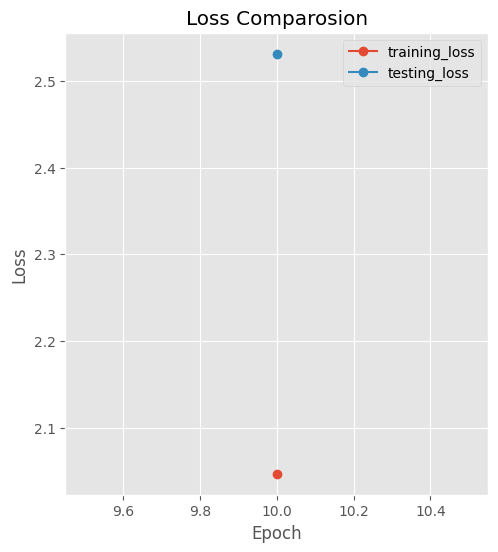

In [97]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(epochs, training_loss, label="training_loss", marker='o')
plt.plot(epochs, testing_loss, label="testing_loss", marker='o')
plt.title("Loss Comparosion")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

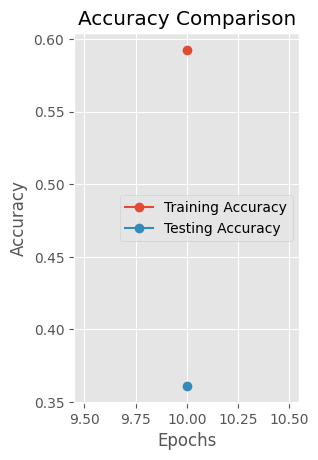

In [98]:
plt.subplot(1, 2, 2)
plt.plot(epochs, training_acc, label='Training Accuracy', marker='o')
plt.plot(epochs, testing_acc, label='Testing Accuracy', marker='o')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Sample knowledge base for disease prevention advice
disease_advice = {
    "Powdery Mildew": "To prevent powdery mildew, ensure good air circulation around plants, avoid overhead watering, and use resistant plant varieties.",
    "Leaf Spot": "Prevent leaf spot by avoiding overhead irrigation, removing affected leaves, and applying fungicides if necessary.",
    "Root Rot": "To prevent root rot, ensure proper drainage in pots and soil, avoid overwatering, and regularly check for root health.",
    "Blight": "Prevent blight by practicing crop rotation, using resistant varieties, and avoiding wet foliage.",
    # Add more diseases and their prevention advice
}

def get_disease_advice(disease_name):
    # Fetch advice based on the detected disease
    return disease_advice.get(disease_name, "No specific advice available for this disease.")

# Example usage
detected_disease = "Powdery Mildew"  # This would be the output of your model
advice = get_disease_advice(detected_disease)
print(f"Detected Disease: {detected_disease}")
print(f"Prevention Advice: {advice}")


Detected Disease: Powdery Mildew
Prevention Advice: To prevent powdery mildew, ensure good air circulation around plants, avoid overhead watering, and use resistant plant varieties.


In [ ]:
# # Assume 'model' is your trained model and 'predict' is your function for prediction
# def predict_and_advise(image):
#     detected_disease = model.predict(image)  # Get the disease from the model
#     advice = get_disease_advice(detected_disease)
#     return detected_disease, advice

# # Example usage
# image = "path/to/plant/image.jpg"
# disease, advice = predict_and_advise(image)
# print(f"Detected Disease: {disease}")
# print(f"Prevention Advice: {advice}")
